In [11]:
import zipfile
zip_ref = zipfile.ZipFile("/content/dataset.zip")
zip_ref.extractall("/content")
zip_ref.close()

In [12]:
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import (Dense,
                          Conv2D,
                          MaxPooling2D,
                          Flatten,
                          BatchNormalization,
                          Dropout
                          )

import cv2

In [13]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/train",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (256, 256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/test",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (256, 256)
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [14]:
def process(image, label):
  image = tf.cast(image/255., tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [15]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), padding="valid", activation = "relu", input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding="valid"))

model.add(Conv2D(64, kernel_size=(3, 3), padding="valid", activation = "relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding="valid"))

model.add(Conv2D(128, kernel_size=(3, 3), padding="valid", activation = "relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding="valid"))

model.add(Flatten())

model.add(Dense(128, activation = "relu"))
model.add(Dropout(0.1))
model.add(Dense(64, activation = "relu"))
model.add(Dropout(0.1))
model.add(Dense(1, activation = "sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [18]:
history = model.fit(train_ds, epochs = 10, validation_data=validation_ds)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 43s 117ms/step - accuracy: 0.5402 - loss: 3.9055 - val_accuracy: 0.5052 - val_loss: 1.7579
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 22s 86ms/step - accuracy: 0.5798 - loss: 0.7388 - val_accuracy: 0.6406 - val_loss: 0.6560
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 22s 86ms/step - accuracy: 0.6778 - loss: 0.6162 - val_accuracy: 0.7029 - val_loss: 0.5879
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.7182 - loss: 0.5540 - val_accuracy: 0.7173 - val_loss: 0.6313
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.7578 - loss: 0.5008 - val_accuracy: 0.7247 - val_loss: 0.5324
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.7657 - loss: 0.5090 - val_accuracy: 0.7415 - val_loss: 0.5487
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - accuracy: 0.8181 - loss: 0.4032 - val_accuracy: 0.7553 - val_loss: 0.5028
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.8515 - loss: 0.3242 -

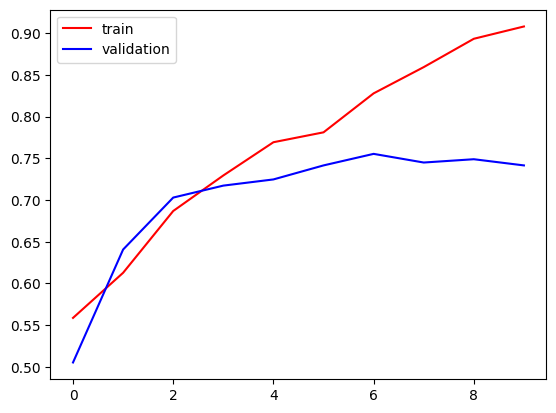

In [19]:
plt.plot(history.history["accuracy"], color = "red", label = "train")
plt.plot(history.history["val_accuracy"], color = "blue", label = "validation")
plt.legend()
plt.show()

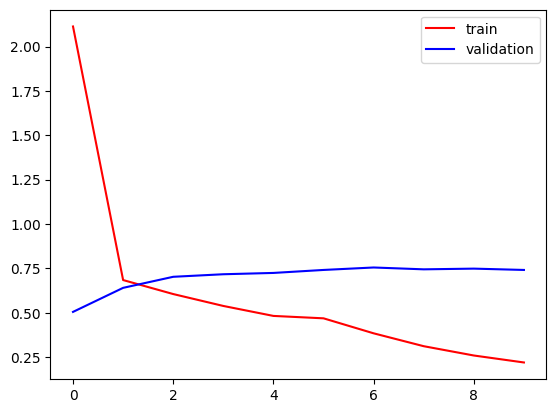

In [20]:
plt.plot(history.history["loss"], color = "red", label = "train")
plt.plot(history.history["val_accuracy"], color = "blue", label = "validation")
plt.legend()
plt.show()

In [32]:
test_image_1 = cv2.imread("/content/test/dogs/dog.4020.jpg")
test_image_2 = cv2.imread("/content/test/cats/cat.4010.jpg")

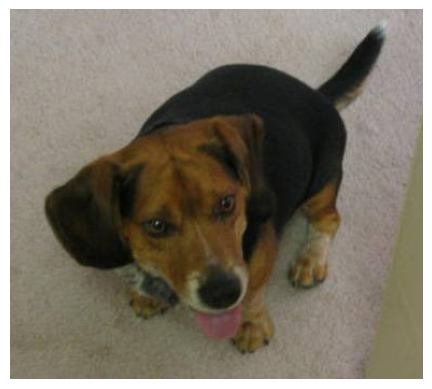

In [35]:
img_1 = cv2.cvtColor(test_image_1, cv2.COLOR_BGR2RGB)
plt.imshow(img_1)
plt.axis("off")
plt.show()

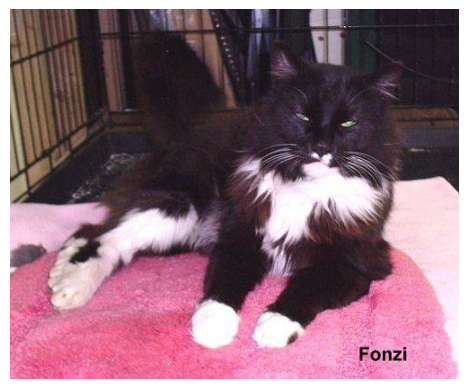

In [36]:
img_2 = cv2.cvtColor(test_image_2, cv2.COLOR_BGR2RGB)
plt.imshow(img_2)
plt.axis("off")
plt.show()

In [37]:
test_image_1.shape

(344, 384, 3)

In [38]:
test_image_2.shape

(412, 500, 3)

In [39]:
test_image_1 = cv2.resize(test_image_1, (256, 256))
test_image_2 = cv2.resize(test_image_2, (256, 256))

In [40]:
test_input_1 = test_image_1.reshape((1, 256, 256, 3))
test_input_2 = test_image_2.reshape((1, 256, 256, 3))

In [41]:
model.predict(test_input_1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[1.]], dtype=float32)

In [42]:
model.predict(test_input_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[0.]], dtype=float32)